In [12]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

In [13]:
import os
DATA_PATH = os.environ.get(
    "MONETARY_DATA_PATH", os.path.join("..", "data", "Monetary_transmission_data_III.xlsx")
)
FEATURE_COLS = ["CPI", "EXR", "M2b", "RSV", "BRNT"]
TARGET_COLS = ["CPI", "EXR"]
TEST_FRAC = 0.15
MIN_TEST = 4
MAXLAGS = 12
MAX_INTEGRATION_ORDER = 2
SIG_LEVEL = 0.05  # ADF / KPSS / Johansen trace test threshold


In [14]:
def load_data(path: str) -> pd.DataFrame:
    """Load raw Excel data and enforce a sorted monthly DatetimeIndex."""
    df = pd.read_excel(path, parse_dates=["DATE"])
    return df.sort_values("DATE").set_index("DATE").asfreq("MS")


def log_transform(df: pd.DataFrame) -> tuple:
    """Log-transform strictly positive series to stabilize variance; others left as-is."""
    out = df.copy()
    log_cols = [c for c in out.columns if (out[c] > 0).all()]
    out[log_cols] = np.log(out[log_cols])
    return out, log_cols


def invert_log(frame: pd.DataFrame, log_cols: list) -> pd.DataFrame:
    """Back-transform log-scaled columns to the original units."""
    out = frame.copy()
    cols = [c for c in log_cols if c in out.columns]
    out[cols] = np.exp(out[cols])
    return out


df_raw = load_data(DATA_PATH)[FEATURE_COLS]
df, LOG_COLS = log_transform(df_raw)
print(f"log-transformed columns: {LOG_COLS}")
df.head()


log-transformed columns: ['CPI', 'EXR', 'M2b', 'RSV', 'BRNT']


,CPI,EXR,M2b,RSV,BRNT
DATE,,,,,
2003-01-01,3.906372,4.572315,13.352670,21.502671,3.427797
2003-02-01,3.895216,4.573282,13.362540,21.525957,3.486228
2003-03-01,3.871867,4.573994,13.373999,21.505301,3.406785
2003-04-01,3.863851,4.574513,13.382558,21.599546,3.220275
2003-05-01,3.887386,4.576902,13.386649,21.586376,3.247057


In [15]:
# Structural-break dates partition the sample into four regimes; "W5" retains
# the entire series as a fifth, unsegmented baseline for comparison.
BREAK_DATES = pd.to_datetime(["2008-06-01", "2016-10-01", "2022-03-01"])
EDGES = [df.index.min(), *BREAK_DATES, df.index.max() + pd.DateOffset(days=1)]

WINDOWS = {f"W{i + 1}": (EDGES[i], EDGES[i + 1] - pd.DateOffset(days=1)) for i in range(len(EDGES) - 1)}
WINDOWS["W5"] = (df.index.min(), df.index.max())

for label, (start, end) in WINDOWS.items():
    print(f"{label}: {start.date()} -> {end.date()} ({len(df.loc[start:end])} months)")


W1: 2003-01-01 -> 2008-05-31 (65 months)
W2: 2008-06-01 -> 2016-09-30 (100 months)
W3: 2016-10-01 -> 2022-02-28 (65 months)
W4: 2022-03-01 -> 2025-10-01 (44 months)
W5: 2003-01-01 -> 2025-10-01 (274 months)


In [16]:
def is_stationary(series: pd.Series, sig_level: float = SIG_LEVEL) -> bool:
    """Stationary only if ADF rejects a unit root and KPSS fails to reject stationarity."""
    s = series.dropna()
    try:
        adf_p = adfuller(s, autolag="AIC")[1]
    except Exception:
        adf_p = 1.0
    try:
        kpss_p = kpss(s, regression="c", nlags="auto")[1]
    except Exception:
        kpss_p = 0.0
    return adf_p < sig_level and kpss_p >= sig_level


def integration_order(series: pd.Series, max_order: int = MAX_INTEGRATION_ORDER, sig_level: float = SIG_LEVEL) -> int:
    """Smallest d such that the d-th difference is stationary by ADF+KPSS agreement."""
    s = series
    for d in range(max_order + 1):
        if is_stationary(s, sig_level):
            return d
        s = s.diff().dropna()
    return max_order


def stationarity_report(train: pd.DataFrame) -> pd.Series:
    """Integration order per series on the training portion of a window."""
    return pd.Series({col: integration_order(train[col]) for col in train.columns}, name="order")


In [17]:
def select_lag_order(train: pd.DataFrame, maxlags: int) -> int:
    """AIC-optimal VAR order in levels, capped so the model stays identified on short windows."""
    cap = max(1, min(maxlags, len(train) // (len(train.columns) + 1) - 1))
    try:
        order = VAR(train).select_order(cap).aic
    except Exception:
        order = 1
    return max(order, 1)


def cointegration_rank(train: pd.DataFrame, k_ar_diff: int, sig_level: float = SIG_LEVEL) -> int:
    """Johansen trace-test rank at `sig_level`; falls back to 0 (no cointegration) if infeasible."""
    cvt_col = {0.10: 0, 0.05: 1, 0.01: 2}[sig_level]
    try:
        result = coint_johansen(train, det_order=0, k_ar_diff=k_ar_diff)
        return int((result.lr1 > result.cvt[:, cvt_col]).sum())
    except Exception:
        return 0


In [18]:
def fit_var_diff(train: pd.DataFrame, lag: int, test_size: int) -> pd.DataFrame:
    """VAR in first differences, integrated back up to levels via cumulative sum."""
    train_diff = train.diff().dropna()
    lag = max(min(lag, len(train_diff) // (len(train.columns) + 1) - 1), 1)
    fitted = VAR(train_diff).fit(lag)
    diff_forecast = fitted.forecast(train_diff.values[-lag:], steps=test_size)
    return pd.DataFrame(diff_forecast, columns=train.columns).cumsum() + train.iloc[-1].values, lag


def fit_forecast_window(train: pd.DataFrame, test_size: int, maxlags: int = MAXLAGS) -> tuple:
    """
    Per-window model selection:
      - all series I(1) and cointegrated  -> VECM
      - all series I(1), not cointegrated -> VAR in first differences
      - all series I(0)                   -> VAR in levels
      - mixed integration orders          -> VAR in first differences (safe fallback)
    """
    orders = stationarity_report(train)
    var_order = select_lag_order(train, maxlags)
    k_ar_diff = max(var_order - 1, 0)

    if (orders == 1).all():
        rank = cointegration_rank(train, k_ar_diff)
        if rank > 0:
            fitted = VECM(train, k_ar_diff=k_ar_diff, coint_rank=rank, deterministic="ci").fit()
            forecast = pd.DataFrame(fitted.predict(steps=test_size), columns=train.columns)
            spec = f"VECM(rank={rank}, k_ar_diff={k_ar_diff})"
        else:
            forecast, lag = fit_var_diff(train, var_order, test_size)
            spec = f"VAR(p={lag}, differenced)"
    elif (orders == 0).all():
        fitted = VAR(train).fit(var_order)
        level_forecast = fitted.forecast(train.values[-var_order:], steps=test_size)
        forecast = pd.DataFrame(level_forecast, columns=train.columns)
        spec = f"VAR(p={var_order}, levels)"
    else:
        forecast, lag = fit_var_diff(train, var_order, test_size)
        spec = f"VAR(p={lag}, differenced, mixed-order)"

    return forecast, spec, orders


def evaluate(forecast_df: pd.DataFrame, actual_df: pd.DataFrame, target_cols: list) -> pd.DataFrame:
    """RMSE and MAE per target series, on the original (non-log) scale."""
    return pd.DataFrame({
        col: {
            "RMSE": np.sqrt(mean_squared_error(actual_df[col], forecast_df[col])),
            "MAE": mean_absolute_error(actual_df[col], forecast_df[col]),
        }
        for col in target_cols
    }).T


In [19]:
def run_window_pipeline(df_window: pd.DataFrame, raw_window: pd.DataFrame) -> dict:
    """Stationarity test -> cointegration test -> lag selection -> fit -> evaluate, within one window."""
    test_size = max(int(len(df_window) * TEST_FRAC), MIN_TEST)
    train, test_index = df_window.iloc[:-test_size], df_window.index[-test_size:]

    forecast_all, spec, orders = fit_forecast_window(train, test_size)
    forecast_all.index = test_index

    forecast_df = invert_log(forecast_all[TARGET_COLS], LOG_COLS)
    actual_df = raw_window.loc[test_index, TARGET_COLS]
    metrics = evaluate(forecast_df, actual_df, TARGET_COLS)

    return {
        "df_window": df_window, "spec": spec, "orders": orders,
        "forecast": forecast_df, "actual": actual_df, "metrics": metrics,
    }


results = {}
for label, (start, end) in WINDOWS.items():
    df_w = df.loc[start:end]
    raw_w = df_raw.loc[start:end]
    results[label] = run_window_pipeline(df_w, raw_w)
    r = results[label]
    print(f"{label}: n={len(df_w)} | integration order={r['orders'].to_dict()} | {r['spec']}")
    display(r["metrics"])


W1: n=65 | integration order={'CPI': 1, 'EXR': 1, 'M2b': 1, 'RSV': 0, 'BRNT': 1} | VAR(p=8, differenced, mixed-order)


,RMSE,MAE
CPI,4.975731,4.304581
EXR,4.210762,3.754520


W2: n=100 | integration order={'CPI': 1, 'EXR': 1, 'M2b': 1, 'RSV': 1, 'BRNT': 1} | VECM(rank=4, k_ar_diff=11)


,RMSE,MAE
CPI,7.028330,6.239605
EXR,15.050028,12.986050


W3: n=65 | integration order={'CPI': 1, 'EXR': 1, 'M2b': 2, 'RSV': 1, 'BRNT': 1} | VAR(p=8, differenced, mixed-order)


,RMSE,MAE
CPI,17.938293,15.719099
EXR,6.925508,5.979135


W4: n=44 | integration order={'CPI': 2, 'EXR': 1, 'M2b': 1, 'RSV': 1, 'BRNT': 1} | VAR(p=5, differenced, mixed-order)


,RMSE,MAE
CPI,29.664595,27.433860
EXR,3.216359,2.949946


W5: n=274 | integration order={'CPI': 2, 'EXR': 2, 'M2b': 1, 'RSV': 1, 'BRNT': 1} | VAR(p=4, differenced, mixed-order)


,RMSE,MAE
CPI,60.233795,47.925501
EXR,239.971525,221.628732


In [20]:
# Model spec and held-out test error per window.
summary_df = pd.concat({label: r["metrics"] for label, r in results.items()}, names=["window", "target"])
spec_df = pd.DataFrame({
    label: {"spec": r["spec"], **{f"order_{c}": o for c, o in r["orders"].items()}}
    for label, r in results.items()
}).T
display(spec_df)
summary_df


,spec,order_CPI,order_EXR,order_M2b,order_RSV,order_BRNT
W1,"VAR(p=8, differenced, mixed-order)",1,1,1,0,1
W2,"VECM(rank=4, k_ar_diff=11)",1,1,1,1,1
W3,"VAR(p=8, differenced, mixed-order)",1,1,2,1,1
W4,"VAR(p=5, differenced, mixed-order)",2,1,1,1,1
W5,"VAR(p=4, differenced, mixed-order)",2,2,1,1,1


RMSE         MAE
window target                        
W1     CPI       4.975731    4.304581
       EXR       4.210762    3.754520
W2     CPI       7.028330    6.239605
       EXR      15.050028   12.986050
W3     CPI      17.938293   15.719099
       EXR       6.925508    5.979135
W4     CPI      29.664595   27.433860
       EXR       3.216359    2.949946
W5     CPI      60.233795   47.925501
       EXR     239.971525  221.628732

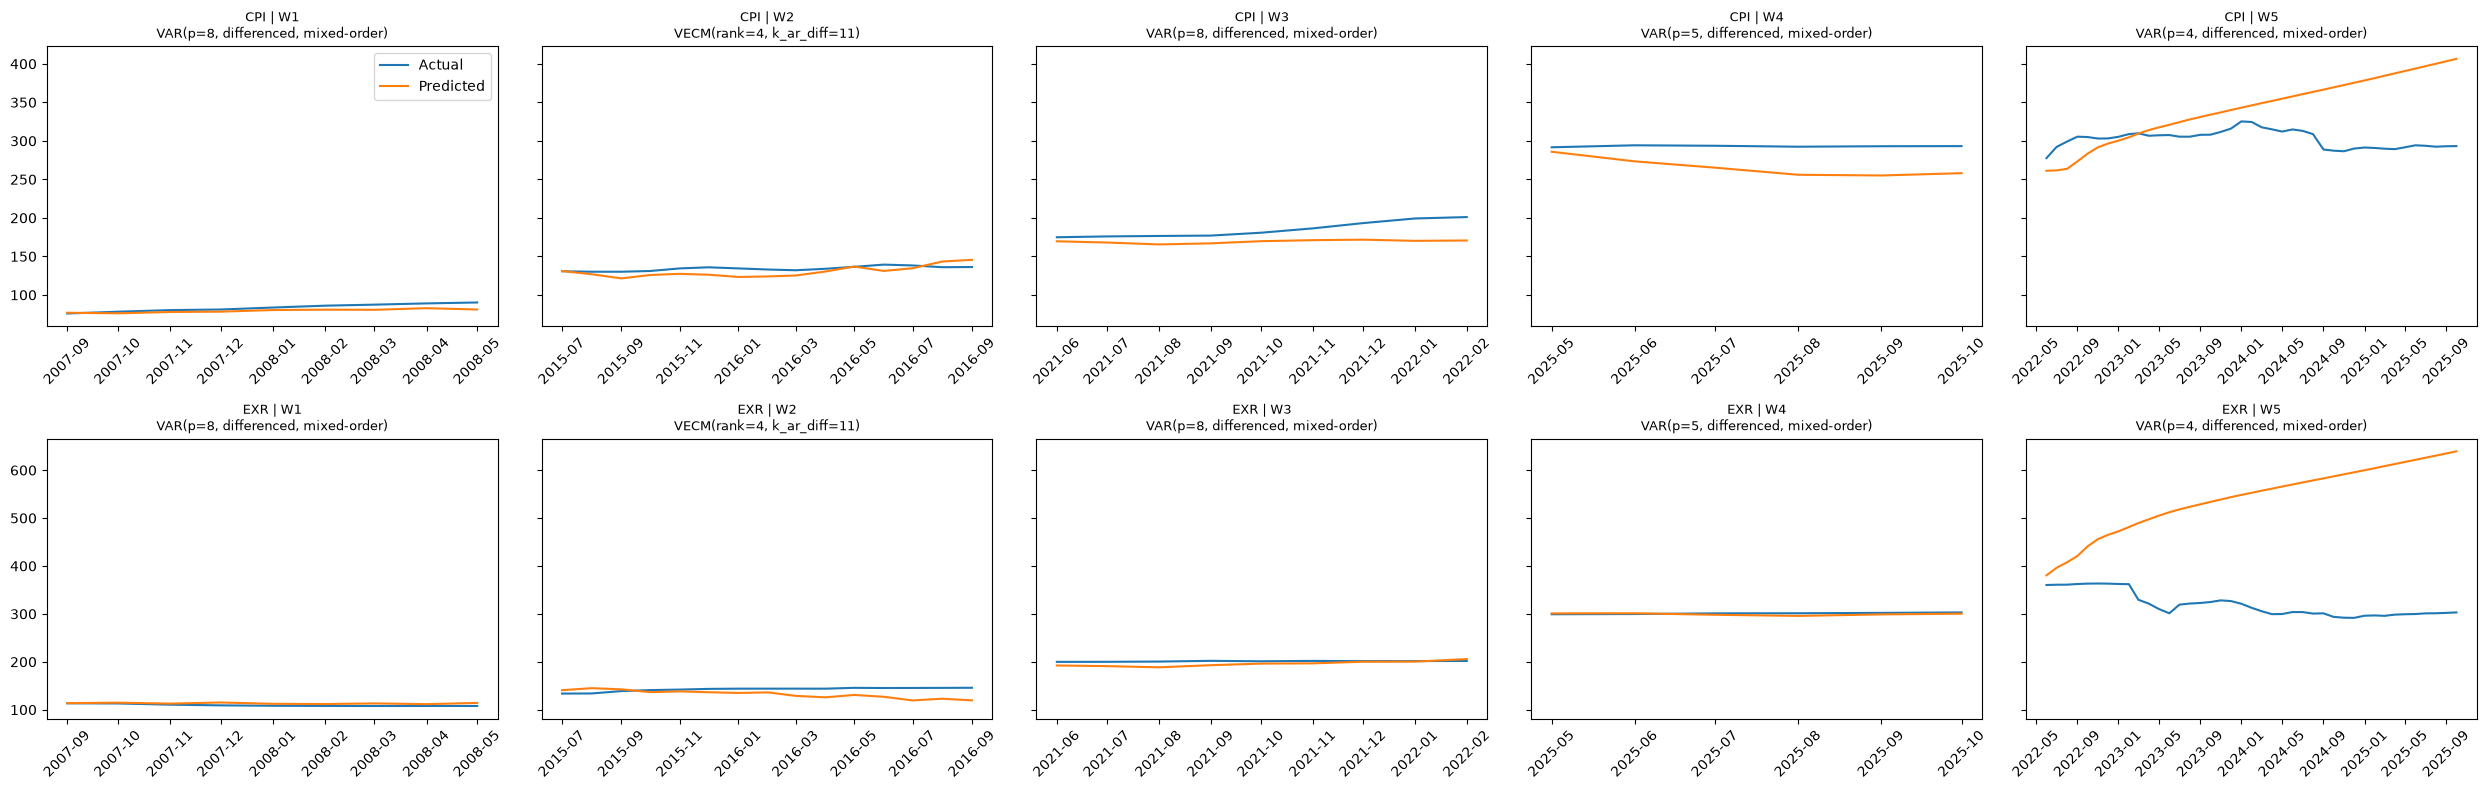

In [22]:
fig, axes = plt.subplots(len(TARGET_COLS), len(WINDOWS), figsize=(5 * len(WINDOWS), 4 * len(TARGET_COLS)), sharey="row")
for col_idx, target in enumerate(TARGET_COLS):
    for win_idx, (label, r) in enumerate(results.items()):
        ax = axes[col_idx, win_idx]
        ax.plot(r["actual"].index, r["actual"][target], label="Actual")
        ax.plot(r["actual"].index, r["forecast"][target], label="Predicted")
        ax.set_title(f"{target} | {label}\n{r['spec']}", fontsize=9)
        ax.tick_params(axis="x", labelrotation=45)
axes[0, 0].legend()
plt.tight_layout()
plt.show()


In [23]:
os.makedirs("../results", exist_ok=True)
# Standardized long-format export consumed by the model-comparison pipeline.
export_rows = [
    {"window": label, "target": col, "RMSE": r["metrics"].loc[col, "RMSE"], "MAE": r["metrics"].loc[col, "MAE"]}
    for label, r in results.items() for col in TARGET_COLS
]
pd.DataFrame(export_rows).to_csv("../results/metrics_var_vecm.csv", index=False)


In [24]:
# Raw test-set predictions, consumed by the ensemble hybrid notebook.
pred_rows = [
    {"window": label, "target": col, "date": date,
     "actual": r["actual"].loc[date, col], "predicted": r["forecast"].loc[date, col]}
    for label, r in results.items()
    for date in r["actual"].index
    for col in TARGET_COLS
]
pd.DataFrame(pred_rows).to_csv("../results/predictions_var_vecm.csv", index=False)
